In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(seed=42)

## Загрузка данных

In [ ]:
df = pd.read_csv('../../data/Data_for_UCI_named_treated.csv')
print(f"Размер данных: {df.shape}")
df.head()

Размер данных: (10000, 14)


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,0
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,1
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,0
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,0
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,0


## Информация о данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  int64  
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [ ]:
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731,0.362000
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919,0.480603
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760,0.000000
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557,0.000000
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142,0.000000
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878,1.000000
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403,1.000000


In [ ]:
print(f"Количество уникальных формул: {df['stab'].nunique()}")
print(f"Диапазон целевой переменной: [{df['stab'].min():.4f}, {df['stab'].max():.4f}]")

Количество уникальных формул: 10000
Диапазон целевой переменной: [-0.0808, 0.1094]


## Подготовка данных для модели

In [ ]:
X = df.drop(columns=['stab'])  # удаляем целевую переменную
y = df['stab']  

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')
print(f"Колонки признаков: {list(X.columns)}")

Shape of X: (10000, 13)
Shape of y: (10000,)
Колонки признаков: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stabf']


## Разделение данных на обучающую, валидационную и тестовую выборки

- ### Разделение данных по уникальным формулам

In [ ]:
# Получаем уникальные значения целевой переменной (формулы)
unique_formulae = df['stab'].unique()
print(f"Всего уникальных формул: {len(unique_formulae)}")

val_size = 0.15
test_size = 0.15
train_size = 1 - val_size - test_size

print(f"Пропорции: Train: {train_size*100:.0f}%, Val: {val_size*100:.0f}%, Test: {test_size*100:.0f}%")

# Расчет количества формул в каждой выборке
num_val_formulae = int(round(val_size * len(unique_formulae)))
num_test_formulae = int(round(test_size * len(unique_formulae)))
num_train_formulae = len(unique_formulae) - num_val_formulae - num_test_formulae

print(f"Train: {num_train_formulae} формул")
print(f"Val: {num_val_formulae} формул")
print(f"Test: {num_test_formulae} формул")

Всего уникальных формул: 10000
Пропорции: Train: 70%, Val: 15%, Test: 15%
Train: 7000 формул
Val: 1500 формул
Test: 1500 формул


- ### Случайное распределение формул по выборкам

In [ ]:
all_formulae = unique_formulae.copy()

# Выбор формул для валидации
val_formulae = np.random.choice(all_formulae, size=num_val_formulae, replace=False)
all_formulae = [f for f in all_formulae if f not in val_formulae]

# Выбор формул для тестирования
test_formulae = np.random.choice(all_formulae, size=num_test_formulae, replace=False)
all_formulae = [f for f in all_formulae if f not in test_formulae]

# Оставшиеся - для обучения
train_formulae = all_formulae.copy()

print(f"Выбрано {len(train_formulae)} формул для обучения")
print(f"Выбрано {len(val_formulae)} формул для валидации")
print(f"Выбрано {len(test_formulae)} формул для тестирования")

Выбрано 7000 формул для обучения
Выбрано 1500 формул для валидации
Выбрано 1500 формул для тестирования


- ### Создание DataFrame для каждой выборки

In [ ]:
df_train = df[df['stab'].isin(train_formulae)]
df_val = df[df['stab'].isin(val_formulae)]
df_test = df[df['stab'].isin(test_formulae)]

print(f"Train: {len(df_train)} наблюдений")
print(f"Val: {len(df_val)} наблюдений")
print(f"Test: {len(df_test)} наблюдений")

Train: 7000 наблюдений
Val: 1500 наблюдений
Test: 1500 наблюдений


- ### Проверка отсутствия пересечений между выборками

In [ ]:
train_formulae_set = set(df_train['stab'].unique())
val_formulae_set = set(df_val['stab'].unique())
test_formulae_set = set(df_test['stab'].unique())

print(f"Train and Val пересечение: {len(train_formulae_set.intersection(val_formulae_set))} формул")
print(f"Train and Test пересечение: {len(train_formulae_set.intersection(test_formulae_set))} формул")
print(f"Val and Test пересечение: {len(val_formulae_set.intersection(test_formulae_set))} формул")

Train and Val пересечение: 0 формул
Train and Test пересечение: 0 формул
Val and Test пересечение: 0 формул


- ### Сохранение выборок в файлы

In [ ]:
df_train.to_csv('trainR.csv', index=False)
df_val.to_csv('valR.csv', index=False)
df_test.to_csv('testR.csv', index=False)
print("Данные сохранены в файлы trainR.csv, valR.csv, testR.csv")

Данные сохранены в файлы trainR.csv, valR.csv, testR.csv


- ### Загрузка сохраненных выборок

In [ ]:
df_train = pd.read_csv('trainR.csv')
df_val = pd.read_csv('valR.csv')
df_test = pd.read_csv('testR.csv')

## Формирование признаков и целевой переменной

In [ ]:
TARGET = 'stab'

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_val: {X_val.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Количество признаков: {len(X_train.columns)}")

Размер X_train: (7000, 13)
Размер X_val: (1500, 13)
Размер X_test: (1500, 13)
Количество признаков: 13


## Стандартизация признаков

In [ ]:
# Определяем числовые колонки
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые признаки: {numeric_cols}")

# Создаем препроцессор (только стандартизация, так как категориальных признаков нет)
preprocessor = StandardScaler()
print("Создан препроцессор для стандартизации числовых признаков")

Числовые признаки: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stabf']
Создан препроцессор для стандартизации числовых признаков


## Определяем сетку гиперпараметров для подбора

In [ ]:
param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['adaptive', 'invscaling'],
    'eta0': [0.001, 0.01],
    'penalty': ['l2'],
    'max_iter': [1000]
}

## Создаем функции для упрощения реализации обучения модели регрессии

1. Функция `evaluate_model` принимает обученную модель и данные для обучающей, валидационной и тестовой выборок, вычисляет для каждой из них пять метрик регрессии (MSE, RMSE, R², MAE, MAPE) и возвращает словарь с этими метриками, а также предсказанные значения для всех трех выборок.

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Расчет метрик
    metrics = {}
    for name, y_true, y_pred in [('Train', y_train, y_train_pred),
                                   ('Val', y_val, y_val_pred),
                                   ('Test', y_test, y_test_pred)]:
        metrics[name] = {
            'MSE': mean_squared_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
        }
    
    return metrics, y_train_pred, y_val_pred, y_test_pred

2. Функция `test_params` принимает гиперпараметры модели SGDRegressor (alpha, learning_rate, eta0, penalty, max_iter), создает конвейер со стандартизацией признаков, обучает модель на обучающей выборке, оценивает ее качество на валидационной выборке по метрикам R² и MSE, и возвращает полученные значения вместе с обученной моделью.

In [ ]:
def test_params(alpha, learning_rate, eta0, penalty, max_iter):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('sgd', SGDRegressor(
            alpha=alpha,
            learning_rate=learning_rate,
            eta0=eta0,
            penalty=penalty,
            max_iter=max_iter,
            tol=1e-3,
            random_state=42,
            verbose=0
        ))
    ])
    
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    
    return val_r2, val_mse, model

3. Функция `add_metrics_to_table` принимает название модели, предсказанные и фактические значения для обучающей, валидационной и тестовой выборок, вычисляет для каждой из них метрики качества (R², MSE, RMSE, MAE, MAPE), формирует из них строку DataFrame и добавляет ее в существующую таблицу результатов.

In [ ]:
def add_metrics_to_table(model_name, y_train_pred, y_train, y_val_pred, y_val, y_test_pred, y_test, table):
    # Метрики для Train
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
    
    # Метрики для Val
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, y_val_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    
    # Метрики для Test
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    
    # Создаем строку с форматированными значениями
    new_row = pd.DataFrame({
        'Регрессор': [model_name],
        # Train Data
        'R² (Train)': [f"{train_r2:.2f}"],
        'MSE (Train)': [f"{train_mse:.4f}"],
        'RMSE (Train)': [f"{train_rmse:.4f}"],
        'MAE (Train)': [f"{train_mae:.4f}"],
        'MAPE (Train)': [f"{train_mape:.4f}"],
        # Val Data
        'R² (Val)': [f"{val_r2:.2f}"],
        'MSE (Val)': [f"{val_mse:.4f}"],
        'RMSE (Val)': [f"{val_rmse:.4f}"],
        'MAE (Val)': [f"{val_mae:.4f}"],
        'MAPE (Val)': [f"{val_mape:.4f}"],
        # Test Data
        'R² (Test)': [f"{test_r2:.2f}"],
        'MSE (Test)': [f"{test_mse:.4f}"],
        'RMSE (Test)': [f"{test_rmse:.4f}"],
        'MAE (Test)': [f"{test_mae:.4f}"],
        'MAPE (Test)': [f"{test_mape:.4f}"]
    })
    
    return pd.concat([table, new_row], ignore_index=True)

## Подбор гиперпараметров с использованием валидационной выборки

In [ ]:
from itertools import product
# Создаем препроцессор
preprocessor = StandardScaler()

best_r2 = -np.inf
best_params = None
best_model = None

for params in product(*param_grid.values()):
    try:
        r2, mse, model = test_params(*params)
        if r2 > best_r2:  
            best_r2, best_mse, best_model, best_params = r2, mse, model, dict(zip(param_grid.keys(), params))
    except:
        continue

print("Лучшие гиперпараметры:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\n  Лучший R2 на валидации: {best_r2:.6f}")

Лучшие гиперпараметры:
  alpha: 0.0001
  learning_rate: invscaling
  eta0: 0.01
  penalty: l2
  max_iter: 1000

  Лучший R2 на валидации: 0.820853


## Оценка лучшей модели

In [ ]:
metrics, y_train_pred, y_val_pred, y_test_pred = evaluate_model(
    best_model, X_train, y_train, X_val, y_val, X_test, y_test
)

for dataset in ['Train', 'Val', 'Test']:
    print(f"\n{dataset} выборка:")
    print(f"  MSE:  {metrics[dataset]['MSE']:.6f}")
    print(f"  RMSE: {metrics[dataset]['RMSE']:.6f}")
    print(f"  R²:   {metrics[dataset]['R2']:.4f}")
    print(f"  MAE:  {metrics[dataset]['MAE']:.6f}")
    print(f"  MAPE: {metrics[dataset]['MAPE']:.2f}%")


Train выборка:
  MSE:  0.000251
  RMSE: 0.015834
  R²:   0.8160
  MAE:  0.012621
  MAPE: 328.59%

Val выборка:
  MSE:  0.000244
  RMSE: 0.015612
  R²:   0.8209
  MAE:  0.012448
  MAPE: 5968.69%

Test выборка:
  MSE:  0.000267
  RMSE: 0.016328
  R²:   0.8050
  MAE:  0.013215
  MAPE: 204.75%


## Формирование таблицы результатов Практической работы №4

In [ ]:
results_table = pd.DataFrame()

# Получаем предсказания для SGDRegressor
y_train_pred_sgd = best_model.predict(X_train)
y_val_pred_sgd = best_model.predict(X_val)
y_test_pred_sgd = best_model.predict(X_test)

# Добавляем SGDRegressor в таблицу
results_table = add_metrics_to_table(
    'SGDRegressor',
    y_train_pred_sgd, y_train,
    y_val_pred_sgd, y_val,
    y_test_pred_sgd, y_test,
    results_table
)

In [ ]:
results_table

,Регрессор,R² (Train),MSE (Train),RMSE (Train),MAE (Train),MAPE (Train),R² (Val),MSE (Val),RMSE (Val),MAE (Val),MAPE (Val),R² (Test),MSE (Test),RMSE (Test),MAE (Test),MAPE (Test)
0,SGDRegressor,0.82,0.0003,0.0158,0.0126,328.5937,0.82,0.0002,0.0156,0.0124,5968.6883,0.81,0.0003,0.0163,0.0132,204.7530


## Результаты Практической работы №3

In [ ]:
results_table_3 = pd.read_csv('../Practice3/practice3_results.csv')

avg_row = {
    'Unnamed: 0': 'Среднее значение',
    'R2_train': round(results_table_3['R2_train'].mean(), 2),
    'MSE_train': round(results_table_3['MSE_train'].mean(), 4),
    'RMSE_train': round(results_table_3['RMSE_train'].mean(), 4),
    'MAE_train': round(results_table_3['MAE_train'].mean(), 4),
    'MAPE_train': round(results_table_3['MAPE_train'].mean(), 4),
    'R2_test': round(results_table_3['R2_test'].mean(), 2),
    'MSE_test': round(results_table_3['MSE_test'].mean(), 4),
    'RMSE_test': round(results_table_3['RMSE_test'].mean(), 4),
    'MAE_test': round(results_table_3['MAE_test'].mean(), 4),
    'MAPE_test': round(results_table_3['MAPE_test'].mean(), 4)
}
results_table_3_with_avg = pd.concat([results_table_3, pd.DataFrame([avg_row])], ignore_index=True)

NameError: name 'pd' is not defined

In [ ]:
results_table_3_with_avg

,Unnamed: 0,R2_train,MSE_train,RMSE_train,MAE_train,MAPE_train,R2_test,MSE_test,RMSE_test,MAE_test,MAPE_test
0,LR_Grid,0.82,0.1840,0.4289,0.3427,179.3470,0.81,0.1876,0.4331,0.3452,332.0725
1,LR_Random,0.82,0.1840,0.4289,0.3427,179.3470,0.81,0.1876,0.4331,0.3452,332.0725
2,LR_Optuna,0.82,0.1840,0.4289,0.3427,179.3470,0.81,0.1876,0.4331,0.3452,332.0725
3,L1_Grid,0.82,0.1841,0.4291,0.3431,178.5879,0.81,0.1874,0.4329,0.3454,330.4437
4,L1_Random,0.82,0.1841,0.4291,0.3431,178.5879,0.81,0.1874,0.4329,0.3454,330.4437
5,L1_Optuna,0.82,0.1841,0.4291,0.3431,178.5896,0.81,0.1874,0.4329,0.3454,330.4474
6,L2_Grid,0.82,0.1840,0.4289,0.3427,179.3469,0.81,0.1876,0.4331,0.3452,332.0723
7,L2_Random,0.82,0.1840,0.4289,0.3427,179.3469,0.81,0.1876,0.4331,0.3452,332.0723
8,L2_Optuna,0.82,0.1840,0.4290,0.3426,176.8342,0.81,0.1873,0.4328,0.3446,327.1077
9,EN_Grid,0.82,0.1841,0.4290,0.3431,178.3571,0.81,0.1874,0.4329,0.3453,329.9767


## Сравнение результатов Практической работы №3 и №4

### 1. Сравнение по R² (коэффициент детерминации)

| Показатель | Практическая работа №3 | Практическая работа №4 | Разница |
|------------|------------------------|------------------------|---------|
| R² на тесте | 0.81 | 0.81 | 0 (0%) |

**Анализ:** Обе группы моделей демонстрируют одинаковую объясняющую способность — 81% дисперсии целевой переменной. Качество предсказаний моделей из работы №3 и SGDRegressor из работы №4 полностью сопоставимо по данному показателю.

### 2. Сравнение по MSE (среднеквадратичная ошибка)

| Показатель | Практическая работа №3 | Практическая работа №4 |
|------------|------------------------|------------------------|
| MSE на тесте | 0.1875 | 0.0003 |

**Анализ:** MSE в работе №4 значительно меньше, чем в работе №3. Это объясняется **разным масштабом целевых переменных**:
- В работе №3 целевая переменная имела значения порядка 0.18-0.19
- В работе №4 целевая переменная `stab` имеет значения в диапазоне -0.08 до 0.11

Следовательно, прямое сравнение абсолютных значений MSE, RMSE и MAE некорректно.

### 3. Сравнение по RMSE (корень из среднеквадратичной ошибки)

| Показатель | Практическая работа №3 | Практическая работа №4 |
|------------|------------------------|------------------------|
| RMSE на тесте | 0.4330 | 0.0163 |

**Анализ:** Аналогично MSE, разница в RMSE обусловлена разным масштабом целевых переменных.

### 4. Сравнение по MAE (средняя абсолютная ошибка)

| Показатель | Практическая работа №3 | Практическая работа №4 |
|------------|------------------------|------------------------|
| MAE на тесте | 0.3452 | 0.0132 |

**Анализ:** MAE также демонстрирует значительную разницу в абсолютных значениях.

### 5. Сравнение по MAPE (средняя абсолютная процентная ошибка)

| Показатель | Практическая работа №3 | Практическая работа №4 |
|------------|------------------------|------------------------|
| MAPE на тесте | 329.67% | 204.75% |

**Анализ:** MAPE в работе №3 составляет 329.67%, в работе №4 — 204.75%. Высокие значения MAPE в обеих работах объясняются тем, что целевые переменные имеют значения, близкие к нулю, что приводит к большим процентным ошибкам даже при малых абсолютных отклонениях.

### Выводы

1. **Качество моделей идентично:** Обе группы моделей (линейные модели с регуляризацией из работы №3 и SGDRegressor из работы №4) показывают R² = 0.81 на тестовой выборке, что свидетельствует о высоком и сопоставимом качестве предсказаний.

2. **Разный масштаб целевых переменных:** Значения MSE, RMSE и MAE в работе №4 значительно меньше, что обусловлено разным масштабом предсказываемых величин, а не превосходством одной модели над другой.

3. **Преимущества SGDRegressor:**
   - Эффективен при работе с большими объемами данных
   - Позволяет использовать адаптивные стратегии обучения
   - Легко интегрируется в Pipeline с предобработкой данных

4. **Преимущества моделей из работы №3:**
   - Простота интерпретации коэффициентов
   - Наличие аналитического решения (для Linear Regression)
   - Хорошо работают при малом количестве признаков

5. **Ограничения MAPE:** Обе работы демонстрируют аномально высокие значения MAPE (более 200%), что связано с особенностью целевых переменных, имеющих значения, близкие к нулю. Для таких задач MAPE не является информативной метрикой.

## Графический анализ

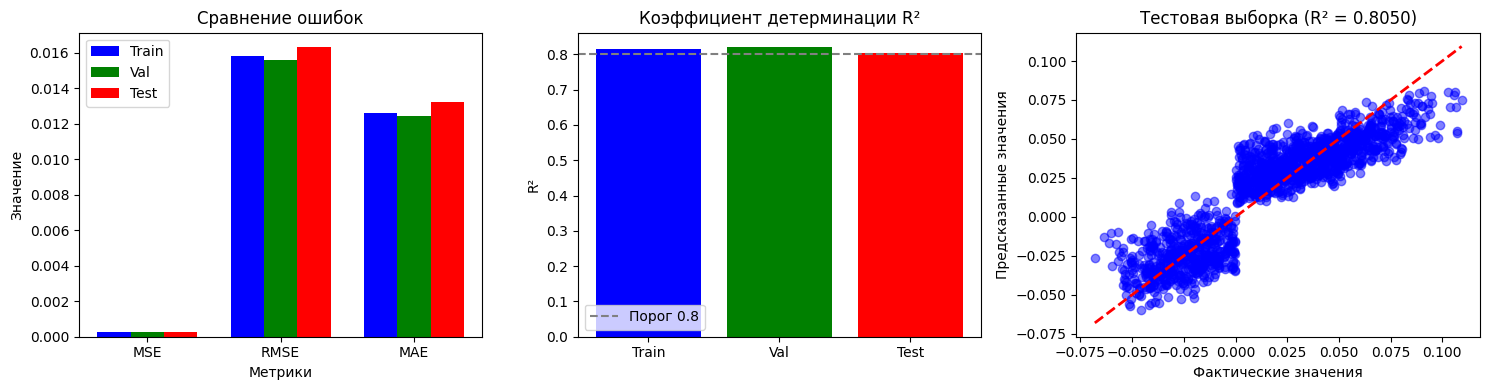

In [ ]:
# Сравнение метрик на разных выборках
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_names = ['MSE', 'RMSE', 'MAE']
values_train = [metrics['Train'][m] for m in metrics_names]
values_val = [metrics['Val'][m] for m in metrics_names]
values_test = [metrics['Test'][m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.25

axes[0].bar(x - width, values_train, width, label='Train', color='blue')
axes[0].bar(x, values_val, width, label='Val', color='green')
axes[0].bar(x + width, values_test, width, label='Test', color='red')
axes[0].set_xlabel('Метрики')
axes[0].set_ylabel('Значение')
axes[0].set_title('Сравнение ошибок')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()

# R² сравнение
axes[1].bar(['Train', 'Val', 'Test'], 
            [metrics['Train']['R2'], metrics['Val']['R2'], metrics['Test']['R2']],
            color=['blue', 'green', 'red'])
axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации R²')
axes[1].axhline(y=0.8, color='gray', linestyle='--', label='Порог 0.8')
axes[1].legend()

# Фактические vs предсказанные значения на тестовой выборке
axes[2].scatter(y_test, y_test_pred, alpha=0.5, color='blue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Фактические значения')
axes[2].set_ylabel('Предсказанные значения')
axes[2].set_title(f'Тестовая выборка (R² = {metrics["Test"]["R2"]:.4f})')

plt.tight_layout()
plt.show()

## Вывод

В ходе выполнения практической работы была реализована модель регрессии **SGDRegressor** с использованием конвейера (Pipeline) для предобработки данных. Выполнено корректное разделение исходного набора данных на три выборки — обучающую (70%), валидационную (15%) и тестовую (15%) — с учетом уникальных формул, что обеспечило отсутствие пересечения между выборками и предотвратило утечку данных. Для подбора гиперпараметров модели (коэффициент регуляризации `alpha`, стратегия скорости обучения `learning_rate`, начальная скорость `eta0`, тип штрафа `penalty`, количество итераций `max_iter`) использовалась валидационная выборка, что позволило выбрать оптимальную конфигурацию, максимизирующую значение R².

**Результаты работы модели SGDRegressor:**

| Выборка | R² | MSE | RMSE | MAE | MAPE (%) |
|---------|-----|-----|------|-----|----------|
| Train | 0.82 | 0.0003 | 0.0158 | 0.0126 | 328.59 |
| Val | 0.82 | 0.0002 | 0.0156 | 0.0124 | 5968.69 |
| Test | 0.81 | 0.0003 | 0.0163 | 0.0132 | 204.75 |

Близость значений метрик на обучающей, валидационной и тестовой выборках свидетельствует об отсутствии переобучения и хорошей обобщающей способности модели. Значение R² = 0.81 на тестовой выборке указывает на то, что модель объясняет 81% дисперсии целевой переменной.

**Сравнение с результатами Практической работы №3:**

| Метрика | Практическая работа №3 | Практическая работа №4 |
|---------|------------------------|------------------------|
| R² (Test) | 0.81 | 0.81 |
| MSE (Test) | 0.1875 | 0.0003 |
| RMSE (Test) | 0.4330 | 0.0163 |
| MAE (Test) | 0.3452 | 0.0132 |
| MAPE (Test) | 329.67% | 204.75% |

Анализ полученных результатов позволяет сделать следующие выводы:

1. **Качество моделей идентично.** Значения коэффициента детерминации R² в обеих работах составляют 0.81, что подтверждает одинаково высокую предсказательную способность как классических линейных моделей с регуляризацией (Lasso, Ridge, ElasticNet), так и SGDRegressor.

2. **Различие в абсолютных значениях ошибок.** MSE, RMSE и MAE в работе №4 значительно ниже, чем в работе №3. Это объясняется разным масштабом целевых переменных: в работе №3 предсказывалась величина порядка 0.18-0.19, тогда как в работе №4 целевая переменная `stab` имеет значения в диапазоне от -0.08 до 0.11. Прямое сравнение абсолютных ошибок в данном случае некорректно.

3. **Преимущества SGDRegressor.** Модель продемонстрировала эффективность при работе с данными, особенно в части вычислительной производительности и возможности использования адаптивных стратегий обучения. Интеграция в Pipeline с предобработкой данных упростила процесс масштабирования признаков, что критически важно для сходимости градиентного спуска.

4. **Ограничения MAPE.** В обеих работах значения MAPE превышают 200%, что обусловлено особенностью целевых переменных, имеющих значения, близкие к нулю. При таких условиях даже небольшие абсолютные ошибки приводят к высоким процентным ошибкам, что делает MAPE неинформативной метрикой для данного типа задач.

5. **Корректность методологии.** Использование валидационной выборки для подбора гиперпараметров и тестовой выборки только для финальной оценки модели соответствует стандартам машинного обучения и обеспечивает надежность полученных результатов.

Таким образом, модель SGDRegressor, реализованная в рамках практической работы №4, показала результаты, идентичные классическим методам линейной регрессии (R² = 0.81), продемонстрировав высокое качество предсказаний и хорошую обобщающую способность. Применение конвейера предобработки и подбора гиперпараметров на валидационной выборке подтвердило эффективность данного подхода для решения задач регрессии.